# Project Work - 1

## General

- All project work in IND320 will result in personal hand-ins and online apps.
    1. A Jupyter Notebook run locally on your computer (later with access to online and local databases).
        - This will be your basic development and documentation platform.
            - Must include a brief description of AI usage.
            - Must include a 300-500-word log describing the compulsory work (including both Jupyter Notebook and Streamlit experience).
            - Must include links to your public GitHub repository and Streamlit app (see below) for the compulsory work.
        - Document headings should be clear and usable for navigation during development.
        - All code blocks must include enough comments to be understandable and reproducible if someone inherits your project.
        - All code blocks must be run before an export to PDF so the messages and plots are shown. In addition, add the .ipynb file to the GitHub repository where you have your Streamlit project.
    2. A Streamlit app running at https://[yourproject].streamlit.app/.
        - This will be an online version of the project, accessing data that has been exported to CSV format (later, also an online database).
        - The code, hosted on GitHub, must include relevant comments from the Jupyter Notebook and further comments regarding Streamlit usage.
- There are four parts in the project work, building on each other and resulting in a final portfolio and app to be presented at the end of the semester.
- Co-operation is applauded, and the use of AI tools is encouraged.

## Tasks

### <font color="pink"> Imports:</font>

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

### <font color="pink"> GitHub and Streamlit.app accounts</font>
- Prepare a GitHub account and create a public repository for your project work. Addresses on streamlit.app must be unique, so include your GitHub username or similar in the repository name. Report the Streamlit address and GitHub repository address in the Jupyter Notebook.
- Log in to share.streamlit.io using your GitHub account.
- Create a minimum working example of a Streamlit app, push it to GitHub, and ensure it works at https://[yourproject].streamlit.app/

### <font color="green"> Answer to the task:</font>


- https://ind320-dakshi.streamlit.app
- https://github.com/dakshiken/IND320

### Jupyter Notebook 
- Read the reservoirs.csv file using Pandas (located in D2Dbook/data).
- Rename headers to English and understandable.
- Print its contents in a relevant way.
- Plot each column separately.
- Plot all columns together. Consider how to make this natural, given that the scales are different.
- Remember to fill in the log and AI mentioned in the General section above.

### <font color="green"> Answer to the task:</font>

In [34]:
#read data
df = pd.read_csv("../data/D2Dbook/data/reservoirs.csv")

#filter for national data only
df = df[(df["omrType"] == "NO") & (df["omrnr"] == 0)].sort_values("dato_Id")

#rename columns to english
df = df.rename(
    columns={
        "dato_Id": "Date",
        "fyllingsgrad": "Fill Degree",
        "kapasitet_TWh": "Capacity (TWh)",
        "fylling_TWh": "Fill Volume (TWh)",
        "fyllingsgrad_forrige_uke": "Fill Degree Previous Week",
        "endring_fyllingsgrad": "Change in Fill Degree",
    }
)

#convert to datetime and set as index
df["Date"] = pd.to_datetime(df["Date"])
df = df[
    [
        "Date",
        "Fill Degree",
        "Capacity (TWh)",
        "Fill Volume (TWh)",
        "Fill Degree Previous Week",
        "Change in Fill Degree",
    ]
].set_index("Date")

#print shape and preview first rows
print(df.shape)
df.head()

(1653, 5)


,Fill Degree,Capacity (TWh),Fill Volume (TWh),Fill Degree Previous Week,Change in Fill Degree
Date,,,,,
1995-01-08,0.608274,87.43758,53.185986,0.752703,-0.144430
1995-01-15,0.582372,87.43758,50.921207,0.608274,-0.025902
1995-01-22,0.562412,87.43758,49.175980,0.582390,-0.019977
1995-01-29,0.534508,87.43758,46.736122,0.562412,-0.027904
1995-02-05,0.506486,87.43758,44.285900,0.534489,-0.028003


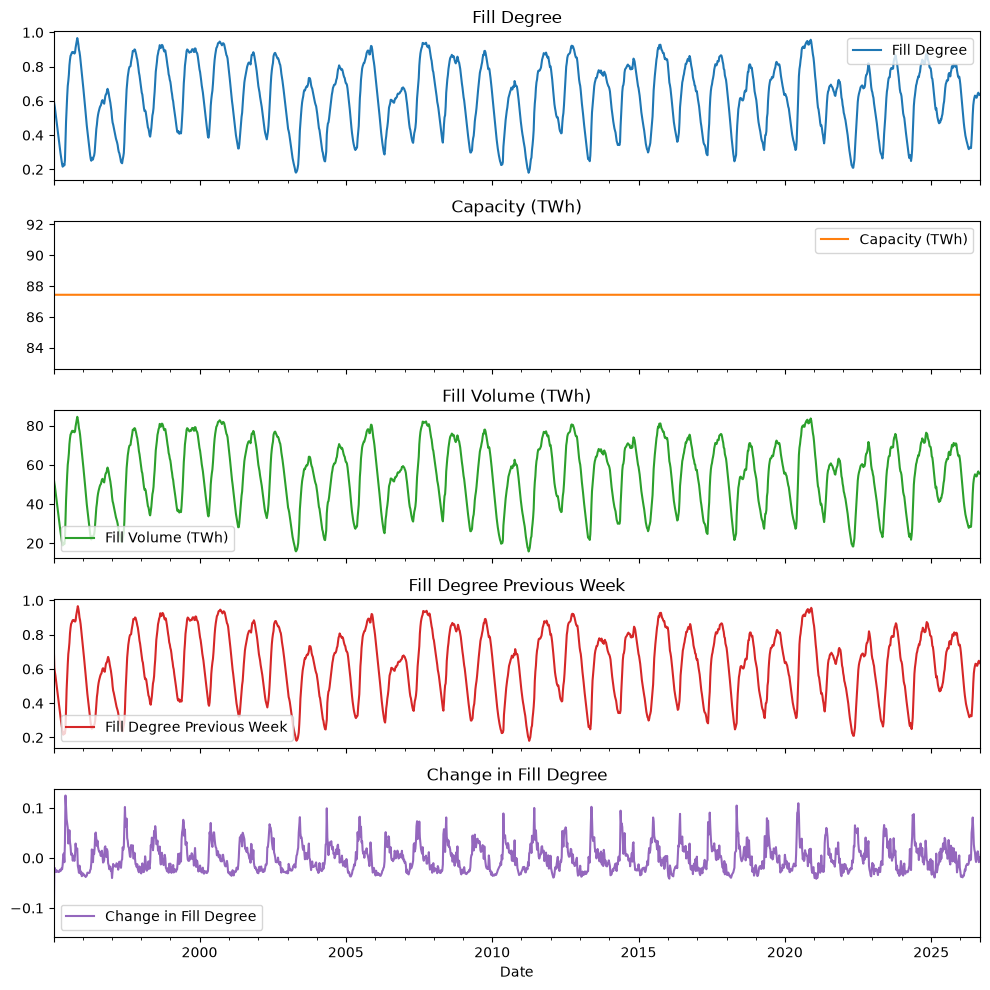

In [35]:
#plot each column separately
df.plot(subplots=True, figsize=(10, 10), title=list(df.columns))
plt.tight_layout()
plt.show()

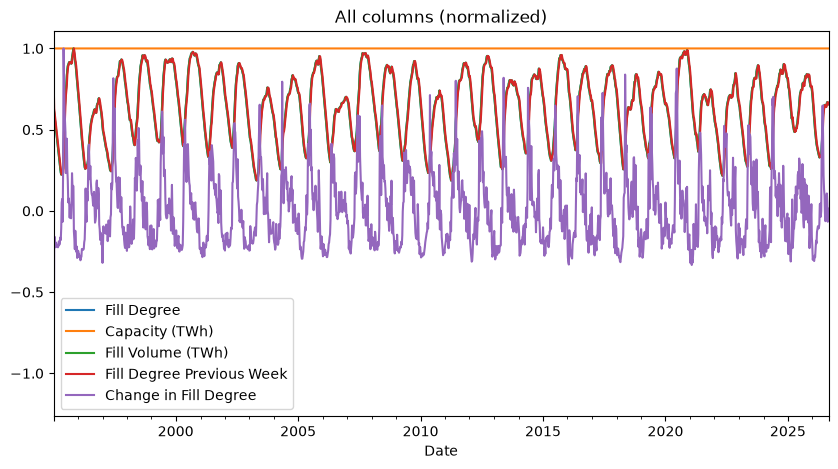

In [36]:
#plot all normalized columns (0-1 scale)
(df / df.max()).plot(figsize=(10, 5), title="All columns (normalized)")
plt.show()

### <font color="pink">Streamlit app</font>
Create a Streamlit app including:
 - requirements.txt or uv.lock (for package dependencies)

 - Four pages (with dummy headers and test content for now) with separate .py files.
 1. The front/home page should have a sidebar menu with navigation options to the other pages.

 2. On the second page:
  - A table showing the imported data (see below). Use the row-wise LineChartColumn() to display the first month of the data series. There should be one row in the table for each column of the imported data.

 3. On the third page:
 - A plot of the imported data (see below), including header, axis titles and other relevant formatting.
 - A drop-down menu (st.selectbox) choosing any single column in the CSV or all columns together.
 - A selection slider (st.select_slider) to select a subset of the months. The default should be the first month.
 
- Data should be read from a local CSV-file (reservoirs.csv), using caching for app speed. In part 2 of the project, we will remove this file and rely on MongoDB instead.

### <font color="green"> Answer to the task:</font>

In [37]:
#streamlit app requirements
!cat ../requirements.txt

streamlit
pandas
matplotlib

In [38]:
#folder structure
!cat ../README.md

 IND320
├── .streamlit/
│   └── config.toml
│
├── data/D2Dbook/                       
│   ├── 0_General/
│   ├── 1_Deployment1/
│   ├── 2_Data_sources/
│   ├── 3_Data_quality/
│   ├── 4_Machine_Learning/
│   ├── 5_Deployment2/
│   ├── 6_Decision_making/
│   ├── 7_Appendix/
│   ├── data/
│   └── images/
│
├── modules/
│   ├── data_loader.py
│
├── notebooks/
│   ├── documentatiom.ipynb
│   ├── reservoirs.ipynb
│
├── pages/
│   ├── Page_2.py
│   ├── Page_3.py
│   ├── Page_4.py
│
├── .gitginore
├── README.md
├── requirements.txt
└── streamlit_app.py

- The app uses Streamlit's multipage setup: `streamlit_app.py` is the entry point (home page), and everything else lives as separate files in the `pages/` folder — `page_2.py`, `page_3.py`, and `page_4.py`. Streamlit automatically lists each one in the sidebar menu.

In [39]:
!cat ../modules/data_loader.py

import pandas as pd
import streamlit as st

#path to CSV file
CSV_PATH = "data/D2Dbook/data/reservoirs.csv"


@st.cache_data  #cache data for speed
def load_data() -> pd.DataFrame:
    """load, clean, and convert reservoir data to englsiih."""
    df = pd.read_csv(CSV_PATH)

    #filter for national data only
    df = df[(df["omrType"] == "NO") & (df["omrnr"] == 0)]

    #rename columns to english
    df = df.rename(
        columns={
            "dato_Id": "Date",
            "fyllingsgrad": "Fill Degree",
            "kapasitet_TWh": "Capacity (TWh)",
            "fylling_TWh": "Fill Volume (TWh)",
            "fyllingsgrad_forrige_uke": "Fill Degree Previous Week",
            "endring_fyllingsgrad": "Change in Fill Degree",
        }
    )

    df["Date"] = pd.to_datetime(df["Date"])  #convert to datetime
    df = df[
        [
            "Date",
            "Fill Degree",
            "Capacity (TWh)",
            "Fill Volume (TWh)",
            "Fill Degree Previous Week",
     

In [40]:
# page 1/homepage of the app
!cat ../streamlit_app.py

import streamlit as st
import random


# Configure page settings
st.set_page_config(
    page_title="IND320", page_icon="💧", layout="wide"
)

# Sidebar info
st.sidebar.title("Navigation")
st.sidebar.info(
    "Use the pages above to explore the other pages:\n\n"
    "- **Page 2** — data loader\n"
    "- **Page 3** — time series plot\n"
    "- **Page 4** — test content"
)

# Main page title and intro
st.title("💧IND320💧")
st.markdown(
    """
    Use the sidebar to navigate between pages.
    """
)

#falling emojis using injected CSS animation

emoji = "Welcome 👋"
count = random.randint(3, 15)
spans = "".join(
    f'<span class="e" style="left:{random.randint(5, 95)}%; animation-delay:{random.uniform(0, 1):.1f}s">{emoji}</span>'
    for _ in range(count)
)

st.markdown(
    f"<style>@keyframes d{{to{{top:100vh;opacity:0}}}}.e{{position:fixed;top:0;font-size:36px;animation:d 3s forwards}}</style>{spans}",
    unsafe_allow_html=True,
)

In [41]:
# page 2 of the app
!cat ../pages/Page_2.py

import pandas as pd
import streamlit as st

from modules.data_loader import load_data

# Page configuration
st.set_page_config(page_title="Data Table", page_icon="📊", layout="wide")

# Page headers
st.title("📊 Data Table")
st.markdown(
    "One row per column of the imported CSV. **First month trend** shows a sparkline "
    "of that column's values during the first calendar month of the series."
)

# Load data
df = load_data()

# Get numeric columns (exclude Date)
value_cols = [c for c in df.columns if c != "Date"]

# Filter data for the first calendar month
first_date = df["Date"].min()
first_month_mask = (
    (df["Date"].dt.year == first_date.year) & (df["Date"].dt.month == first_date.month)
)
first_month = df.loc[first_month_mask]

# Create one row per column with lists for sparklines
table_rows = [
    {"Column": col, "First month trend": first_month[col].tolist()}
    for col in value_cols
]
summary_df = pd.DataFrame(table_rows)

# Display summary table with sparkline chart
st.d

In [42]:
# page 3 of the app
!cat ../pages/Page_3.py

import matplotlib.pyplot as plt
import streamlit as st

from modules.data_loader import load_data

# Page configuration
st.set_page_config(page_title="Data Plot", page_icon="📈", layout="wide")

# Page title
st.title("📈 Data Plot")

# Load cached data
df = load_data()

# Get numeric value columns
value_cols = [c for c in df.columns if c != "Date"]

# UI layout for filter controls
col1, col2 = st.columns([1, 2])

with col1:
    # Dropdown for column selection
    column_choice = st.selectbox("Column to plot", options=["All columns"] + value_cols)

with col2:
    # Slider for month range (defaults to first month)
    month_labels = sorted(df["Date"].dt.to_period("M").astype(str).unique())
    start_month, end_month = st.select_slider(
        "Month range", options=month_labels, value=(month_labels[0], month_labels[0])
    )

# Filter dataset by selected month range
month_str = df["Date"].dt.to_period("M").astype(str)
plot_df = df.loc[month_str.between(start_month, end_month)].set_index("

In [43]:
# page 4 of the app
!cat ../pages/Page_4.py

import streamlit as st

# Configure page settings
st.set_page_config(page_title="Dummy headers", page_icon="👍", layout="wide")

# Page title
st.title("Dummy headers 👍")

# Project info and placeholder text
st.markdown(
    """
    test content , i didnt know what to write here 😀
    """
)

st.balloons()
st.snow()

In [44]:
# short summary of my git log
!git log --oneline

ee831c4 (HEAD -> main, origin/main) test
c70b471 test
9212fd4 first commit


### <font color="pink"> AI usage </font> 

Ai was used to a limited extent during the development of this application.

**Models Used:**
- Google Gemini

**Scope of Usage:**
- Streamlit syntax lookups and HTML/CSS styling syntax
- Debugging (pasting error outputs)
- learn about streamlit , how it works , tips (like https://docs.streamlit.io/develop/api-reference/status/) , etc

### <font color="pink"> Log describing  </font> 

For this compulsory hand in, I set up a public github repository and connected it to streamlit community cloud, deploying a minimal working app before building out any real functionality to confirm the whole pipeline worked end to end. My development setup follows the task description fairly closely, with a few practical choices:
* Developed locally in vscode, no Docker.
* .streamlit/config.toml set with runOnSave = true, so the app auto reloaded in the browser on every file save.
* The streamlit_app.py, pages/, and modules/ folders are synced with my github repo and deployed via streamlit community cloud.

jupyter was used mainly for the required notebook task, not for building the app itself:
1. reading, cleaning, and plotting the reservoir data.
2. writing this report.
* most of the app building and debugging (import errors, file paths, caching) happened directly in the Streamlit .py files.

In the jupyter notebook, I read reservoirs.csv with pandas and filtered it down to the national aggregate series (omrType == "NO", omrnr == 0), since the raw file mixes several regions into one file and plotting them together would have been misleading. I renamed the norwegian and abbreviated headers to clear english names, printed the shape and a preview of the cleaned data, and plotted each column separately as subplots. For the combined plot, I normalized the columns before plotting them on one shared axis, since the raw scales a 0 -1 fraction versus values in twh aren't directly comparable otherwise.

The app was built iteratively, starting from a minimum working example before adding the real pages:
* Got a bare bones app deployed and confirmed working on streamlit.app first, before writing any real logic.
* Centralized csv loading into modules/data_loader.py using @st.cache_data, so every page shares one cached, cleaned dataframe instead of rereading the csv on every page load.
* Most iteration happened locally by running streamlit run streamlit_app.py and using browser auto reload to test changes commits to gitHub were made after features were fully working locally, rather than after every small change.
* I built four pages: a home page (streamlit_app.py) with sidebar navigation, a data table page showing one row per column with LineChartColumn sparklines of the first month, a plot page with a selectbox for choosing a single column or all columns and a select_slider for the month range defaulting to the first month, and a dummy test fourth page.